In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.models.intermediate import intermediate_model
from src.algos.EXP3 import simple_exp3
from src.algos.UCB1 import simple_ucb1

K = 2
T = 10000
n_runs = 10

alpha = [0.9, 0.1]
sigma = [0.1] * K

betas = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]  # range to sweep

In [2]:
model = intermediate_model(K, T)
model.gen(alpha, betas[0], sigma)
exp3 = simple_exp3(model)
ucb1 = simple_ucb1(model)

reg1, wk_reg1 = exp3.eval(n_runs=n_runs, graph=False)
reg, wk_reg = ucb1.eval(n_runs=n_runs, graph=False)

print(reg1, wk_reg1, reg, wk_reg)

⠏: [XXXXXXXXX-] (9 / 10) | ⠏: [XXXXXXXXX-] (9999 / 10000)Final cumulative regret: 39.423172850077705
Regret at T/2: 34.273951378100634
Ratio (should be ~1 for log, ~1.4 for sqrt): 1.1502371703563532
0.09673944947810846 0.09822553115522717 0.2467425708517637 0.25619967353128087


In [4]:
active, rewards = model.play(0)
print("rewards:", rewards)
print("best arm:", model.best)
print("Z_norm:", model.Z)

rewards: [0.76709229 0.2867137 ]
best arm: 0
Z_norm: [0.7 0.3]


⠼: [XXXXXXXX--] (4 / 5) | ⠏: [XXXXXXXXX-] (9999 / 10000)

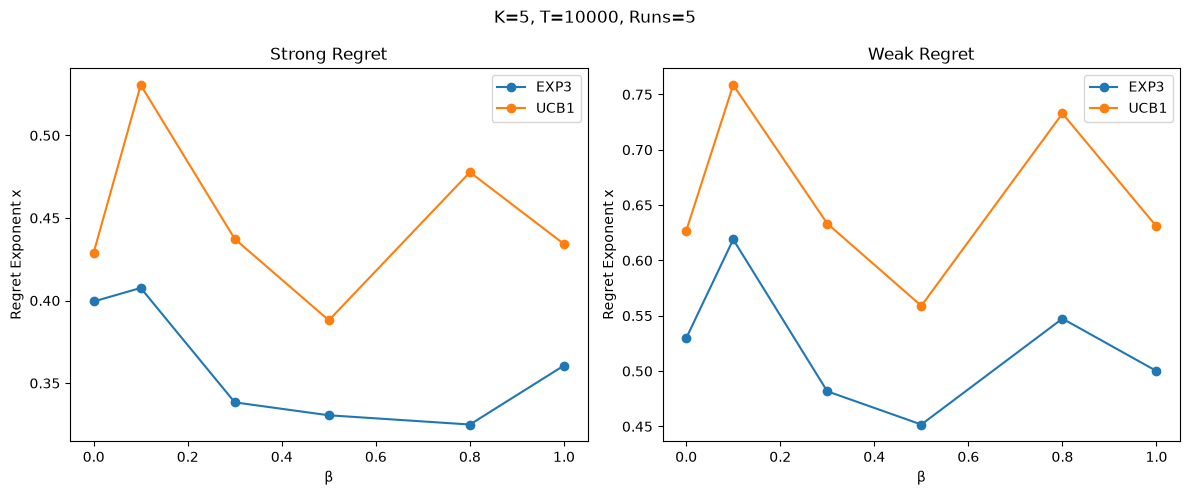

In [4]:
exp3_scores = []
exp3_wk_scores = []
ucb1_scores = []
ucb1_wk_scores = []

for beta_val in betas:
    beta = [beta_val] * K
    
    model = intermediate_model(K, T)
    model.gen(alpha, beta, sigma)
    
    # EXP3
    exp3 = simple_exp3(model)
    reg, wk_reg = exp3.eval(n_runs=n_runs, graph=False)
    exp3_scores.append(reg)
    exp3_wk_scores.append(wk_reg)
    
    # UCB1
    ucb1 = simple_ucb1(model)
    reg, wk_reg = ucb1.eval(n_runs=n_runs, graph=False)
    ucb1_scores.append(reg)
    ucb1_wk_scores.append(wk_reg)

# plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(betas, exp3_scores, label='EXP3', marker='o')
plt.plot(betas, ucb1_scores, label='UCB1', marker='o')
plt.xlabel('β')
plt.ylabel('Regret Exponent x')
plt.title('Strong Regret')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(betas, exp3_wk_scores, label='EXP3', marker='o')
plt.plot(betas, ucb1_wk_scores, label='UCB1', marker='o')
plt.xlabel('β')
plt.ylabel('Regret Exponent x')
plt.title('Weak Regret')
plt.legend()

plt.suptitle(f'K={K}, T={T}, Runs={n_runs}')
plt.tight_layout()
plt.show()